<a href="https://colab.research.google.com/github/FiloEmad/Solship_ML_Hackathon/blob/main/Solship_ML_Hackathon_Model.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [551]:
# =========================================
# CELL 1 — IMPORTS
# =========================================

import pandas as pd
import numpy as np

# Prepare train data

In [552]:
# =========================================
# CELL 2 — LOAD MAIN DATASET
# =========================================

df_2024 = pd.read_csv(
    '/content/ENERGY_Hackathon_DataSet(Sheet1).csv',
    sep=';'
)

# Ensure timestamp is datetime
df_2024["timestamp"] = pd.to_datetime(df_2024["timestamp"])

# Sort by time
df_2024 = df_2024.sort_values("timestamp").reset_index(drop=True)

df_2024.head()

,battery_p,grid_p,load_p,pv_p,timestamp,Selling_price_eur_kwh
0,0,"3,04","3,05",0,2024-01-01 00:00:00,"0,10709"
1,0,"0,34","0,34",0,2024-01-01 00:15:00,"0,10709"
2,0,"0,37","0,37",0,2024-01-01 00:30:00,"0,10709"
3,0,"0,37","0,37",0,2024-01-01 00:45:00,"0,10709"
4,0,"2,4","2,4",0,2024-01-01 01:00:00,"0,104"


In [553]:
# =========================================
# CELL 3 — BASIC TIME FEATURES
# =========================================

df_2024["hour"] = df_2024["timestamp"].dt.hour
df_2024["minute"] = df_2024["timestamp"].dt.minute
df_2024["dayofweek"] = df_2024["timestamp"].dt.dayofweek
df_2024["day"] = df_2024["timestamp"].dt.day
df_2024["month"] = df_2024["timestamp"].dt.month
df_2024["weekofyear"] = df_2024["timestamp"].dt.isocalendar().week.astype(int)

# Weekend flag
df_2024["is_weekend"] = (df_2024["dayofweek"] >= 5).astype(int)

df_2024.head()

,battery_p,grid_p,load_p,pv_p,timestamp,Selling_price_eur_kwh,hour,minute,dayofweek,day,month,weekofyear,is_weekend
0,0,"3,04","3,05",0,2024-01-01 00:00:00,"0,10709",0,0,0,1,1,1,0
1,0,"0,34","0,34",0,2024-01-01 00:15:00,"0,10709",0,15,0,1,1,1,0
2,0,"0,37","0,37",0,2024-01-01 00:30:00,"0,10709",0,30,0,1,1,1,0
3,0,"0,37","0,37",0,2024-01-01 00:45:00,"0,10709",0,45,0,1,1,1,0
4,0,"2,4","2,4",0,2024-01-01 01:00:00,"0,104",1,0,0,1,1,1,0


In [554]:
# =========================================
# CELL 4 — CYCLICAL ENCODING
# =========================================

import numpy as np
import pandas as pd
import holidays

# -----------------------------------------
# 2. CYCLICAL ENCODING (تمثيل الدائرة الزمنية)
# -----------------------------------------
# الساعة (دورة 24 ساعة)
df_2024["hour_sin"] = np.sin(2 * np.pi * df_2024["hour"] / 24)
df_2024["hour_cos"] = np.cos(2 * np.pi * df_2024["hour"] / 24)

# يوم الأسبوع (دورة 7 أيام)
df_2024["dow_sin"] = np.sin(2 * np.pi * df_2024["dayofweek"] / 7)
df_2024["dow_cos"] = np.cos(2 * np.pi * df_2024["dayofweek"] / 7)

# الشهر (دورة 12 شهر)
df_2024["month_sin"] = np.sin(2 * np.pi * df_2024["month"] / 12)
df_2024["month_cos"] = np.cos(2 * np.pi * df_2024["month"] / 12)

# # اليوم في السنة (دورة 365 يوم) - مهم جداً للمواسم صيف/شتاء
# df_2024["doy_sin"] = np.sin(2 * np.pi * df_2024["day_of_year"] / 365)
# df_2024["doy_cos"] = np.cos(2 * np.pi * df_2024["day_of_year"] / 365)

# -----------------------------------------
# 3. BINARY FEATURES (قواعد العمل والإجازات)
# -----------------------------------------
holidays = holidays.IT()
df_2024['is_holiday'] = df_2024['timestamp'].dt.date.apply(lambda x: 1 if x in holidays else 0)

# الويك إند (جمعة وسبت في مصر)
df_2024['is_weekend'] = df_2024['dayofweek'].isin([4, 5]).astype(int)

# ساعات العمل (مثلاً من 8 ص لـ 4 م)
df_2024['is_business_hour'] = df_2024['hour'].between(8, 16).astype(int)

# -----------------------------------------
# 4. INTERACTION FEATURES (دمج الوقت بالنوع)
# -----------------------------------------
# الموديل هيعرف إن "الساعة 10" يوم "الجمعة" ليها وضع خاص
df_2024['hour_weekend_interaction'] = df_2024['hour'] * df_2024['is_weekend']


df_2024.head()

,battery_p,grid_p,load_p,pv_p,timestamp,Selling_price_eur_kwh,hour,minute,dayofweek,day,...,is_weekend,hour_sin,hour_cos,dow_sin,dow_cos,month_sin,month_cos,is_holiday,is_business_hour,hour_weekend_interaction
0,0,"3,04","3,05",0,2024-01-01 00:00:00,"0,10709",0,0,0,1,...,0,0.000000,1.000000,0.0,1.0,0.5,0.866025,1,0,0
1,0,"0,34","0,34",0,2024-01-01 00:15:00,"0,10709",0,15,0,1,...,0,0.000000,1.000000,0.0,1.0,0.5,0.866025,1,0,0
2,0,"0,37","0,37",0,2024-01-01 00:30:00,"0,10709",0,30,0,1,...,0,0.000000,1.000000,0.0,1.0,0.5,0.866025,1,0,0
3,0,"0,37","0,37",0,2024-01-01 00:45:00,"0,10709",0,45,0,1,...,0,0.000000,1.000000,0.0,1.0,0.5,0.866025,1,0,0
4,0,"2,4","2,4",0,2024-01-01 01:00:00,"0,104",1,0,0,1,...,0,0.258819,0.965926,0.0,1.0,0.5,0.866025,1,0,0


In [555]:
# df_2024["load_p"] = np.log1p(
#     df_2024["load_p"]
# )

In [556]:
# =========================================
# LAG FEATURES
# =========================================

target = "load_p"

df_2024["lag_1"] = df_2024[target].shift(1)

# df_2024["lag_2"] = df_2024[target].shift(2)

# df_2024["lag_3"] = df_2024[target].shift(3)

# df_2024["lag_4"] = df_2024[target].shift(4)

# df_2024["lag_8"] = df_2024[target].shift(8)

# # 3 hours ago
# df_2024["lag_12"] = df_2024[target].shift(12)

# # 6 hours ago
# df_2024["lag_24"] = df_2024[target].shift(24)

# 12 hours ago
# df_2024["lag_48"] = df_2024[target].shift(48)

# df_2024["lag_72"] = df_2024[target].shift(72)

# 24 hours ago
df_2024["lag_96"] = df_2024[target].shift(96)

df_2024["lag_192"] = df_2024[target].shift(192)

# 3 days ago
df_2024["lag_288"] = df_2024[target].shift(288)

# 1 week ago
df_2024["lag_672"] = df_2024[target].shift(672)

# 2 weeks ago
df_2024["lag_1344"] = df_2024[target].shift(1344)

df_2024.head()

,battery_p,grid_p,load_p,pv_p,timestamp,Selling_price_eur_kwh,hour,minute,dayofweek,day,...,month_cos,is_holiday,is_business_hour,hour_weekend_interaction,lag_1,lag_96,lag_192,lag_288,lag_672,lag_1344
0,0,"3,04","3,05",0,2024-01-01 00:00:00,"0,10709",0,0,0,1,...,0.866025,1,0,0,None,None,None,None,None,None
1,0,"0,34","0,34",0,2024-01-01 00:15:00,"0,10709",0,15,0,1,...,0.866025,1,0,0,"3,05",None,None,None,None,None
2,0,"0,37","0,37",0,2024-01-01 00:30:00,"0,10709",0,30,0,1,...,0.866025,1,0,0,"0,34",None,None,None,None,None
3,0,"0,37","0,37",0,2024-01-01 00:45:00,"0,10709",0,45,0,1,...,0.866025,1,0,0,"0,37",None,None,None,None,None
4,0,"2,4","2,4",0,2024-01-01 01:00:00,"0,104",1,0,0,1,...,0.866025,1,0,0,"0,37",None,None,None,None,None


In [557]:
import numpy as np
# =========================================
# CELL 6 — ROLLING FEATURES
# =========================================

# Convert target column to numeric, handling commas as decimal separators
df_2024[target] = df_2024[target].astype(str).str.replace(',', '.').astype(float)

df_2024["same_time_3day_avg"] = pd.concat([
    df_2024[target].shift(96),
    df_2024[target].shift(192),
    df_2024[target].shift(288)
], axis=1).mean(axis=1)

# # Last 6 hour mean
# df_2024["rolling_mean_24"] = (
#      df_2024[target]
#     .shift(48)
#      .rolling(window=24)
#      .mean()
#  )

# df_2024["rolling_mean_48"] = (
#      df_2024[target]
#     .shift(48)
#      .rolling(window=48)
#      .mean()
#  )

# df_2024["rolling_mean_48_96"] = (
#      df_2024[target]
#     .shift(96)
#      .rolling(window=48)
#      .mean()
#  )

# # Last 24 hour mean
df_2024["rolling_mean_96"] = (
    df_2024[target]
    .shift(48)
    .rolling(window=96)
    .mean()
)

# # Rolling standard deviation
df_2024["rolling_std_96"] = (
    df_2024[target]
    .shift(48)
    .rolling(window=96)
    .std()
)

# # Rolling max
df_2024["rolling_max_96"] = (
    df_2024[target]
    .shift(48)
    .rolling(window=96)
    .max()
)

# # Rolling min
df_2024["rolling_min_96"] = (
    df_2024[target]
    .shift(48)
    .rolling(window=96)
    .min()
)

df_2024.head()

,battery_p,grid_p,load_p,pv_p,timestamp,Selling_price_eur_kwh,hour,minute,dayofweek,day,...,lag_96,lag_192,lag_288,lag_672,lag_1344,same_time_3day_avg,rolling_mean_96,rolling_std_96,rolling_max_96,rolling_min_96
0,0,"3,04",3.05,0,2024-01-01 00:00:00,"0,10709",0,0,0,1,...,None,None,None,None,None,NaN,NaN,NaN,NaN,NaN
1,0,"0,34",0.34,0,2024-01-01 00:15:00,"0,10709",0,15,0,1,...,None,None,None,None,None,NaN,NaN,NaN,NaN,NaN
2,0,"0,37",0.37,0,2024-01-01 00:30:00,"0,10709",0,30,0,1,...,None,None,None,None,None,NaN,NaN,NaN,NaN,NaN
3,0,"0,37",0.37,0,2024-01-01 00:45:00,"0,10709",0,45,0,1,...,None,None,None,None,None,NaN,NaN,NaN,NaN,NaN
4,0,"2,4",2.40,0,2024-01-01 01:00:00,"0,104",1,0,0,1,...,None,None,None,None,None,NaN,NaN,NaN,NaN,NaN


In [558]:
def same_window_prev_day_avg(df, target):

    shifted = df[target].shift(96)  # نفس الوقت امبارح

    result = []

    for i in range(len(df)):
        start = max(0, i - 6)
        end = min(len(shifted), i + 7)

        window = shifted.iloc[start:end]

        result.append(window.mean())

    return pd.Series(result)

df_2024["prev_day_3h_window_avg"] = same_window_prev_day_avg(df_2024, target)



In [559]:
# =========================================
# CELL 7 — EMA FEATURES
# =========================================

df_2024["ema_24"] = (
    df_2024[target]
    .shift(48)
    .ewm(span=24, adjust=False)
    .mean()
)

df_2024["ema_96"] = (
    df_2024[target]
    .shift(48)
    .ewm(span=96, adjust=False)
    .mean()
)

df_2024.head()

,battery_p,grid_p,load_p,pv_p,timestamp,Selling_price_eur_kwh,hour,minute,dayofweek,day,...,lag_672,lag_1344,same_time_3day_avg,rolling_mean_96,rolling_std_96,rolling_max_96,rolling_min_96,prev_day_3h_window_avg,ema_24,ema_96
0,0,"3,04",3.05,0,2024-01-01 00:00:00,"0,10709",0,0,0,1,...,None,None,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,0,"0,34",0.34,0,2024-01-01 00:15:00,"0,10709",0,15,0,1,...,None,None,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,0,"0,37",0.37,0,2024-01-01 00:30:00,"0,10709",0,30,0,1,...,None,None,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,0,"0,37",0.37,0,2024-01-01 00:45:00,"0,10709",0,45,0,1,...,None,None,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,0,"2,4",2.40,0,2024-01-01 01:00:00,"0,104",1,0,0,1,...,None,None,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [560]:
# =========================================
# CELL 8 — DIFFERENCE FEATURES
# =========================================

df_2024["diff_96"] = df_2024[target].shift(48).diff(96)

df_2024.head()

,battery_p,grid_p,load_p,pv_p,timestamp,Selling_price_eur_kwh,hour,minute,dayofweek,day,...,lag_1344,same_time_3day_avg,rolling_mean_96,rolling_std_96,rolling_max_96,rolling_min_96,prev_day_3h_window_avg,ema_24,ema_96,diff_96
0,0,"3,04",3.05,0,2024-01-01 00:00:00,"0,10709",0,0,0,1,...,None,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,0,"0,34",0.34,0,2024-01-01 00:15:00,"0,10709",0,15,0,1,...,None,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,0,"0,37",0.37,0,2024-01-01 00:30:00,"0,10709",0,30,0,1,...,None,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,0,"0,37",0.37,0,2024-01-01 00:45:00,"0,10709",0,45,0,1,...,None,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,0,"2,4",2.40,0,2024-01-01 01:00:00,"0,104",1,0,0,1,...,None,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [561]:
# =========================================
# CELL 9 — LOAD TEMPERATURE DATASET
# =========================================

# Example:
temp1 = pd.read_csv("/content/weather_15min_2024.csv")
temp2 = pd.read_csv("/content/weather_15min_2025.csv")

temp1["timestamp"] = pd.to_datetime(temp1["timestamp"])
temp2["timestamp"] = pd.to_datetime(temp2["timestamp"])

# Combine temp1 and temp2 by concatenating them vertically
temp_df = pd.concat([temp1, temp2], ignore_index=True)

# Sort by timestamp
temp_df = temp_df.sort_values("timestamp").reset_index(drop=True)

# Keep only needed columns
temp_df = temp_df[
    ["timestamp", "temperature"]
].copy()

temp_df.head()

,timestamp,temperature
0,2024-01-01 00:00:00,7.400
1,2024-01-01 00:15:00,7.425
2,2024-01-01 00:30:00,7.450
3,2024-01-01 00:45:00,7.475
4,2024-01-01 01:00:00,7.500


In [562]:
# =========================================
# CELL 10 — MERGE TEMPERATURE DATA
# =========================================

df_2024 = pd.merge(
    df_2024,
    temp_df,
    on="timestamp",
    how="left"
)

df_2024.head()

,battery_p,grid_p,load_p,pv_p,timestamp,Selling_price_eur_kwh,hour,minute,dayofweek,day,...,same_time_3day_avg,rolling_mean_96,rolling_std_96,rolling_max_96,rolling_min_96,prev_day_3h_window_avg,ema_24,ema_96,diff_96,temperature
0,0,"3,04",3.05,0,2024-01-01 00:00:00,"0,10709",0,0,0,1,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,7.400
1,0,"0,34",0.34,0,2024-01-01 00:15:00,"0,10709",0,15,0,1,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,7.425
2,0,"0,37",0.37,0,2024-01-01 00:30:00,"0,10709",0,30,0,1,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,7.450
3,0,"0,37",0.37,0,2024-01-01 00:45:00,"0,10709",0,45,0,1,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,7.475
4,0,"2,4",2.40,0,2024-01-01 01:00:00,"0,104",1,0,0,1,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,7.500


In [563]:
# =========================================
# CELL 11 — HANDLE MISSING VALUES
# =========================================

# Remove rows created by lag/rolling
df_2024 = df_2024.dropna().reset_index(drop=True)

df_2024.shape
df_2024.head()

,battery_p,grid_p,load_p,pv_p,timestamp,Selling_price_eur_kwh,hour,minute,dayofweek,day,...,same_time_3day_avg,rolling_mean_96,rolling_std_96,rolling_max_96,rolling_min_96,prev_day_3h_window_avg,ema_24,ema_96,diff_96,temperature
0,0,"3,29",3.29,0,2024-01-15 00:00:00,"0,0855",0,0,0,15,...,1.826667,2.418958,1.210067,4.87,0.35,2.843846,2.982768,2.608980,-2.54,-0.200
1,0,"3,02",3.02,0,2024-01-15 00:15:00,"0,0855",0,15,0,15,...,2.326667,2.413958,1.203437,4.87,0.35,3.011538,3.044947,2.632712,-0.48,-0.275
2,0,"3,28",3.28,0,2024-01-15 00:30:00,"0,0855",0,30,0,15,...,2.910000,2.435417,1.229556,4.92,0.35,2.949231,3.194951,2.679873,2.06,-0.350
3,0,"3,31",3.31,0,2024-01-15 00:45:00,"0,0855",0,45,0,15,...,2.913333,2.453229,1.241222,4.92,0.35,2.823077,3.267355,2.709154,1.71,-0.425
4,0,"3,33",3.33,0,2024-01-15 01:00:00,"0,0834",1,0,0,15,...,2.696667,2.475208,1.259179,4.92,0.35,2.706154,3.368367,2.746697,2.11,-0.500


In [564]:
# =========================================
# CELL 12 — FEATURE LIST
# =========================================

feature_cols = [
    col for col in df_2024.columns
    if col not in ["timestamp", target, "battery_p", "grid_p","pv_p","Selling_price_eur_kwh"]
]

X_train = df_2024[feature_cols]

y_train = df_2024[target]

print("Feature count:", len(feature_cols))

print("\nFeatures:")
print(feature_cols)

print("\nX_train shape:", X_train.shape)
print("y_train shape:", y_train.shape)

Feature count: 32

Features:
['hour', 'minute', 'dayofweek', 'day', 'month', 'weekofyear', 'is_weekend', 'hour_sin', 'hour_cos', 'dow_sin', 'dow_cos', 'month_sin', 'month_cos', 'is_holiday', 'is_business_hour', 'hour_weekend_interaction', 'lag_1', 'lag_96', 'lag_192', 'lag_288', 'lag_672', 'lag_1344', 'same_time_3day_avg', 'rolling_mean_96', 'rolling_std_96', 'rolling_max_96', 'rolling_min_96', 'prev_day_3h_window_avg', 'ema_24', 'ema_96', 'diff_96', 'temperature']

X_train shape: (68722, 32)
y_train shape: (68722,)


In [565]:
# =========================================================
# CELL 2 — OPTIMIZED MODEL
# =========================================================
import lightgbm as lgb # Added this import to resolve NameError

model = LGBMRegressor(

    # -----------------------------------------
    # Core
    # -----------------------------------------
    objective="regression",
    metric="rmse",  # Explicit metric for monitoring

    # -----------------------------------------
    # Trees — IMPROVED
    # -----------------------------------------
    n_estimators=5000,  # ↑ Increased (use early_stopping to find optimal)
    learning_rate=0.03,  # ↑ Slightly higher for faster convergence

    num_leaves=127,  # ↑ Increased (2^7 - 1, more capacity)
    max_depth=8,  # ↓ Reduced to prevent overfitting

    min_child_samples=20,  # NEW: Minimum samples per leaf
    min_split_gain=0.01,  # NEW: Minimum gain to split

    # -----------------------------------------
    # Regularization — IMPROVED
    # -----------------------------------------
    subsample=0.85,  # ↑ Slightly increased
    subsample_freq=1,  # NEW: Enable bagging every iteration
    colsample_bytree=0.85,  # ↑ Slightly increased

    reg_alpha=0.1,  # ↓ L1 regularization (less aggressive)
    reg_lambda=1.0,  # ↑ L2 regularization (more aggressive)

    min_gain_to_split=0.01,  # NEW: Additional regularization

    # -----------------------------------------
    # Categorical Features (if any)
    # -----------------------------------------
    #categorical_feature=['hour', 'dayofweek', 'month', 'is_weekend'],  # Uncomment if using

    # -----------------------------------------
    # Stability
    # -----------------------------------------
    random_state=42,
    force_row_wise=True,  # NEW: Better for tall datasets

    # -----------------------------------------
    # Speed
    # -----------------------------------------
    n_jobs=-1,
    verbose=-1  # NEW: Suppress training output
)

# =========================================================
# CELL 3 — TRAIN WITH EARLY STOPPING
# =========================================================

# Create validation set (last 20% of training data)
split_point = int(len(X_train) * 0.8)

X_train_fit = X_train[:split_point].copy() # Make explicit copies
y_train_fit = y_train[:split_point].copy()

X_val = X_train[split_point:].copy()
y_val = y_train[split_point:].copy()

# Convert problematic 'object' columns to numeric (float)
problematic_cols = [col for col in X_train_fit.columns if X_train_fit[col].dtype == 'object']
for col in problematic_cols:
    X_train_fit[col] = X_train_fit[col].astype(str).str.replace(',', '.').astype(float)
    X_val[col] = X_val[col].astype(str).str.replace(',', '.').astype(float)

# Train with early stopping
model.fit(
    X_train_fit,
    y_train_fit,
    eval_set=[(X_val, y_val)],
    eval_metric='rmse',
    callbacks=[
        lgb.early_stopping(stopping_rounds=100, verbose=False),
        lgb.log_evaluation(period=100)
    ]
)

print(f"Best iteration: {model.best_iteration_}")
print(f"Best score: {model.best_score_['valid_0']['rmse']:.4f}")

# Retrain on full data with optimal iterations
params = model.get_params()
params['n_estimators'] = model.best_iteration_ # Update n_estimators
model_final = LGBMRegressor(**params)

[100]	valid_0's rmse: 0.736734
[200]	valid_0's rmse: 0.735306
Best iteration: 148
Best score: 0.7340


In [566]:
# Create a copy of X_train to avoid SettingWithCopyWarning
X_train_copy = X_train.copy()

# Convert problematic 'object' columns in X_train_copy to numeric (float) if any still exist
problematic_cols_X_train = [col for col in X_train_copy.columns if X_train_copy[col].dtype == 'object']
for col in problematic_cols_X_train:
    # Ensure explicit conversion, handling potential commas as decimal separators
    X_train_copy[col] = X_train_copy[col].astype(str).str.replace(',', '.').astype(float)

model_final.fit(X_train_copy, y_train)

LGBMRegressor(colsample_bytree=0.85, force_row_wise=True, learning_rate=0.03,
              max_depth=8, metric='rmse', min_gain_to_split=0.01,
              min_split_gain=0.01, n_estimators=148, n_jobs=-1, num_leaves=127,
              objective='regression', random_state=42, reg_alpha=0.1,
              reg_lambda=1.0, subsample=0.85, subsample_freq=1, verbose=-1)

In [567]:

feature_cols = [
    col for col in df_2024.columns
    if col not in ["battery_p", "grid_p","pv_p","Selling_price_eur_kwh"]
]

df_2024 = df_2024[feature_cols]

df_2024.tail()

,load_p,timestamp,hour,minute,dayofweek,day,month,weekofyear,is_weekend,hour_sin,...,same_time_3day_avg,rolling_mean_96,rolling_std_96,rolling_max_96,rolling_min_96,prev_day_3h_window_avg,ema_24,ema_96,diff_96,temperature
68717,2.55,2025-12-30 23:00:00,23,0,1,30,12,1,0,-0.258819,...,1.160000,2.247708,1.068273,4.24,0.26,2.231818,2.716025,2.282235,1.34,2.000
68718,2.58,2025-12-30 23:15:00,23,15,1,30,12,1,0,-0.258819,...,1.433333,2.241979,1.062349,4.24,0.26,2.192000,2.743543,2.298272,-0.55,1.525
68719,2.64,2025-12-30 23:30:00,23,30,1,30,12,1,0,-0.258819,...,2.600000,2.238333,1.060145,4.24,0.26,2.123333,2.740060,2.306555,-0.35,1.050
68720,2.02,2025-12-30 23:45:00,23,45,1,30,12,1,0,-0.258819,...,2.410000,2.237292,1.059974,4.24,0.26,2.282500,2.709655,2.307657,-0.10,0.575
68721,0.31,2025-12-31 00:00:00,0,0,2,31,12,1,0,0.000000,...,1.886667,2.237083,1.059925,4.24,0.26,2.501429,2.690482,2.311004,-0.02,0.100


In [568]:
temp_2026 = pd.read_csv("/content/weather_15min_2026.csv")

# Ensure timestamp is datetime
temp_2026["timestamp"] = pd.to_datetime(temp_2026["timestamp"])

# Set timestamp as index
temp_2026 = temp_2026.set_index("timestamp")

# Rename the temperature column to 'temperature'
temp_2026 = temp_2026.rename(columns={'temperature_2m (°C)': 'temperature'})

# Keep only the temperature column
temp_2026 = temp_2026[['temperature']]

temp_2026.head()

,temperature
timestamp,
2026-01-01 00:00:00,-4.600
2026-01-01 00:15:00,-4.675
2026-01-01 00:30:00,-4.750
2026-01-01 00:45:00,-4.825
2026-01-01 01:00:00,-4.900


In [571]:
import pandas as pd
import numpy as np
import holidays

# =========================================================
# PREPARE DATA
# =========================================================

history = df_2024.copy()

# تأكد إن الـ timestamp index
history['timestamp'] = pd.to_datetime(history['timestamp'])
history = history.set_index('timestamp')

temp_2026.index = pd.to_datetime(temp_2026.index)

# create prediction column
temp_2026['load_p'] = np.nan

# Italy holidays
italy_holidays = holidays.IT()

def holiday_lookup(date):
    return 1 if date.date() in italy_holidays else 0

# =========================================================
# RECURSIVE FORECASTING
# =========================================================

feature_cols = [col for col in feature_cols
                if col not in ['load_p', 'timestamp']]

for t in temp_2026.index:

    row = {}

    # =====================================================
    # TIME FEATURES
    # =====================================================

    row['hour'] = t.hour
    row['minute'] = t.minute
    row['dayofweek'] = t.dayofweek
    row['day'] = t.day
    row['month'] = t.month
    row['weekofyear'] = t.isocalendar().week

    # =====================================================
    # CALENDAR FEATURES
    # =====================================================

    row['is_weekend'] = int(t.dayofweek >= 5)
    row['is_holiday'] = holiday_lookup(t)
    row['is_business_hour'] = 1 if 8 <= t.hour <= 18 else 0

    # =====================================================
    # CYCLICAL FEATURES
    # =====================================================

    row['hour_sin'] = np.sin(2*np.pi*t.hour/24)
    row['hour_cos'] = np.cos(2*np.pi*t.hour/24)

    row['dow_sin'] = np.sin(2*np.pi*t.dayofweek/7)
    row['dow_cos'] = np.cos(2*np.pi*t.dayofweek/7)

    row['month_sin'] = np.sin(2*np.pi*t.month/12)
    row['month_cos'] = np.cos(2*np.pi*t.month/12)

    # =====================================================
    # INTERACTION
    # =====================================================

    row['hour_weekend_interaction'] = (
        row['hour'] * row['is_weekend']
    )

    # =====================================================
    # LAG FEATURES
    # =====================================================

    load_series = history['load_p']

    row['lag_1'] = load_series.iloc[-1]
    row['lag_96'] = load_series.iloc[-96]
    row['lag_192'] = load_series.iloc[-192]
    row['lag_288'] = load_series.iloc[-288]
    row['lag_672'] = load_series.iloc[-672]
    row['lag_1344'] = load_series.iloc[-1344]

    # =====================================================
    # ROLLING FEATURES
    # =====================================================

    last_96 = load_series.iloc[-96:]

    row['rolling_mean_96'] = last_96.mean()
    row['rolling_std_96'] = last_96.std()
    row['rolling_max_96'] = last_96.max()
    row['rolling_min_96'] = last_96.min()

    # =====================================================
    # EMA FEATURES
    # =====================================================

    row['ema_24'] = load_series.ewm(span=24).mean().iloc[-1]
    row['ema_96'] = load_series.ewm(span=96).mean().iloc[-1]

    # =====================================================
    # SAME TIME 3 DAY AVG
    # =====================================================

    vals = []

    for d in [1, 2, 3]:

        ts = t - pd.Timedelta(days=d)

        if ts in history.index:
            vals.append(history.loc[ts, 'load_p'])

    if len(vals) > 0:
        row['same_time_3day_avg'] = np.mean(vals)
    else:
        row['same_time_3day_avg'] = load_series.iloc[-96:].mean()

    # =====================================================
    # PREV DAY 3H WINDOW AVG
    # =====================================================

    center = t - pd.Timedelta(days=1)

    window_start = center - pd.Timedelta(hours=1, minutes=30)
    window_end = center + pd.Timedelta(hours=1, minutes=45)

    window_vals = history.loc[
        window_start:window_end,
        'load_p'
    ]

    if len(window_vals) > 0:
        row['prev_day_3h_window_avg'] = window_vals.mean()
    else:
        row['prev_day_3h_window_avg'] = load_series.iloc[-96:].mean()

    # =====================================================
    # DIFF_96
    # =====================================================

    ts1 = t - pd.Timedelta(hours=12)
    ts2 = ts1 - pd.Timedelta(days=1)

    if ts1 in history.index and ts2 in history.index:

        row['diff_96'] = (
            history.loc[ts1, 'load_p']
            - history.loc[ts2, 'load_p']
        )

    else:
        row['diff_96'] = 0

    # =====================================================
    # TEMPERATURE
    # =====================================================

    row['temperature'] = temp_2026.loc[t, 'temperature']

    # =====================================================
    # BUILD MODEL INPUT
    # =====================================================

    X = pd.DataFrame([row])

    X = X[feature_cols]

    # force numeric
    X = X.apply(pd.to_numeric, errors='coerce')

    # fill NaNs
    X = X.fillna(0)

    # =====================================================
    # PREDICT
    # =====================================================

    y_pred = model_final.predict(X)[0]

    # =====================================================
    # SAVE PREDICTION
    # =====================================================

    temp_2026.loc[t, 'load_p'] = y_pred

    # =====================================================
    # UPDATE HISTORY
    # =====================================================

    new_row = pd.DataFrame({
        'load_p': [y_pred]
    }, index=[t])

    history = pd.concat([history, new_row])

print("Forecasting completed.")

Forecasting completed.


In [574]:
from google.colab import files

temp_2026.to_csv("temp_2026_forecast.csv")

files.download("temp_2026_forecast.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

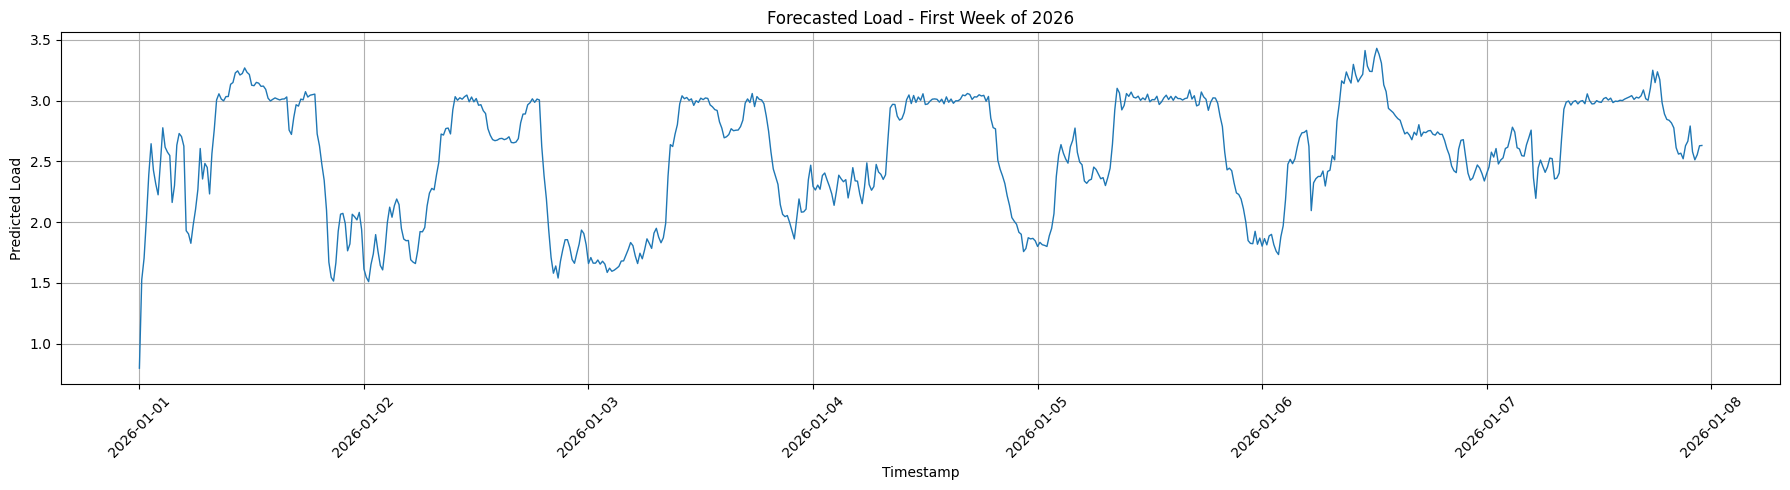

In [573]:
import matplotlib.pyplot as plt

# تأكد إن الـ index datetime
temp_2026.index = pd.to_datetime(temp_2026.index)

# plot
plt.figure(figsize=(18,5))

plt.plot(
    temp_2026.index,
    temp_2026['load_p'],
    linewidth=1
)

plt.title('Forecasted Load - First Week of 2026')
plt.xlabel('Timestamp')
plt.ylabel('Predicted Load')

plt.xticks(rotation=45)

plt.grid(True)

plt.tight_layout()
plt.show()

In [579]:
output_filename = "temp_2026_forecasted_data.csv"
temp_2026.to_csv(output_filename)

print(f"Forecasted data saved to: {output_filename}")

Forecasted data saved to: temp_2026_forecasted_data.csv


In [580]:
from google.colab import files
files.download(output_filename)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
import pandas as pd
import numpy as np

!pip install xlsxwriter # Install xlsxwriter package

# =========================================================
# 1. LOAD DATA
# =========================================================

file_path = "/content/2nd_DataSet_All_Features.xlsx"
df = pd.read_excel(file_path)

df["timestamp"] = pd.to_datetime(df["timestamp"])
df = df.sort_values("timestamp").reset_index(drop=True)

# =========================================================
# 2. FEATURE ENGINEERING
# =========================================================

df["hour"] = df["timestamp"].dt.hour
df["minute"] = df["timestamp"].dt.minute
df["day"] = df["timestamp"].dt.day
df["month"] = df["timestamp"].dt.month
df["dayofweek"] = df["timestamp"].dt.dayofweek
df["weekofyear"] = df["timestamp"].dt.isocalendar().week.astype(int)

df["is_weekend"] = (df["dayofweek"] >= 5).astype(int)

df["hour_sin"] = np.sin(2 * np.pi * df["hour"] / 24)
df["hour_cos"] = np.cos(2 * np.pi * df["hour"] / 24)

df["lag_96"] = df["load_p"].shift(96)

df["rolling_mean_96"] = df["load_p"].rolling(96).mean()
df["rolling_std_96"] = df["load_p"].rolling(96).std()
df["rolling_max_96"] = df["load_p"].rolling(96).max()
df["rolling_min_96"] = df["load_p"].rolling(96).min()

df["same_time_3day_avg"] = df["load_p"].shift(96*3).rolling(3).mean()

df["prev_day_3h_window_avg"] = df["load_p"].shift(96).rolling(12).mean()

df["ema_24"] = df["load_p"].ewm(span=24).mean()
df["ema_96"] = df["load_p"].ewm(span=96).mean()

df["diff_96"] = df["load_p"] - df["lag_96"]

df["temperature"] = df["tempreture"]

df = df.dropna().reset_index(drop=True)

# =========================================================
# 3. TRAIN / TEST SPLIT
# =========================================================

split_idx = int(len(df) * 0.8)

train_df = df.iloc[:split_idx].copy()
test_df = df.iloc[split_idx:].copy()

# =========================================================
# 4. FEATURES
# =========================================================

target = "load_p"

features = [
    "hour","minute","day","month","dayofweek","weekofyear","is_weekend",
    "hour_sin","hour_cos",
    "same_time_3day_avg",
    "rolling_mean_96","rolling_std_96",
    "rolling_max_96","rolling_min_96",
    "prev_day_3h_window_avg",
    "ema_24","ema_96",
    "diff_96",
    "temperature"
]

X_train = train_df[features]
y_train = train_df[target]

X_test = test_df[features]
y_test = test_df[target]

# =========================================================
# 5. TRAIN MODEL (plug yours here)
# =========================================================

model.fit(X_train, y_train)
pred = model.predict(X_test)

# =========================================================
# 6. CREATE RESULTS DATAFRAME
# =========================================================

test_results = test_df.copy()

test_results["prediction"] = pred

# =========================================================
# 7. SAVE TO EXCEL (SAME FILE, MULTI-SHEETS)
# =========================================================

output_file = "model_results.xlsx"

with pd.ExcelWriter(output_file, engine="xlsxwriter") as writer:

    df.to_excel(writer, sheet_name="full_data", index=False)
    train_df.to_excel(writer, sheet_name="train_data", index=False)
    test_df.to_excel(writer, sheet_name="test_data", index=False)

    test_results.to_excel(writer, sheet_name="test_results", index=False)

print(f"Saved results to: {output_file}")

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd

# match lengths safely
matched_index = test_2026_index[:len(predictions)]

# build dataframe
results_df = pd.DataFrame({
    'predicted_load': predictions
}, index=matched_index)

# plot
plt.figure(figsize=(15,5))

plt.plot(
    results_df.index,
    results_df['predicted_load'],
    label='Predicted Load'
)

plt.title('Load Forecast - First Week of 2026')
plt.xlabel('Time')
plt.ylabel('Load')

plt.legend()
plt.grid(True)

plt.show()

In [ ]:
# =========================================
# CELL 13 — SAVE FINAL FEATURED DATASET
# =========================================

output_path = "/content/featured_train_dataset.csv"

df_2024.to_csv(
    output_path,
    index=False
)

print(f"Dataset saved to:\n{output_path}")

# 2026 test

# Prepare Test data

In [ ]:
# =========================================
# CELL 2 — LOAD MAIN DATASET
# =========================================

df_2025 = pd.read_csv("/content/time_load_2025.csv")

# Ensure timestamp is datetime
df_2025["timestamp"] = pd.to_datetime(df_2025["timestamp"])

# Sort by time
df_2025 = df_2025.sort_values("timestamp").reset_index(drop=True)

df_2025.head()

In [ ]:
# =========================================
# CELL 3 — BASIC TIME FEATURES
# =========================================

df_2025["hour"] = df_2025["timestamp"].dt.hour
df_2025["minute"] = df_2025["timestamp"].dt.minute
df_2025["dayofweek"] = df_2025["timestamp"].dt.dayofweek
df_2025["day"] = df_2025["timestamp"].dt.day
df_2025["month"] = df_2025["timestamp"].dt.month
df_2025["weekofyear"] = df_2025["timestamp"].dt.isocalendar().week.astype(int)

# Weekend flag
df_2025["is_weekend"] = (df_2025["dayofweek"] >= 5).astype(int)

df_2025.head()

In [ ]:
# =========================================
# CELL 4 — CYCLICAL ENCODING
# =========================================

import numpy as np
import pandas as pd
import holidays

# -----------------------------------------
# 2. CYCLICAL ENCODING (تمثيل الدائرة الزمنية)
# -----------------------------------------
# الساعة (دورة 24 ساعة)
df_2025["hour_sin"] = np.sin(2 * np.pi * df_2025["hour"] / 24)
df_2025["hour_cos"] = np.cos(2 * np.pi * df_2025["hour"] / 24)

# يوم الأسبوع (دورة 7 أيام)
df_2025["dow_sin"] = np.sin(2 * np.pi * df_2025["dayofweek"] / 7)
df_2025["dow_cos"] = np.cos(2 * np.pi * df_2025["dayofweek"] / 7)

# الشهر (دورة 12 شهر)
df_2025["month_sin"] = np.sin(2 * np.pi * df_2025["month"] / 12)
df_2025["month_cos"] = np.cos(2 * np.pi * df_2025["month"] / 12)

# # اليوم في السنة (دورة 365 يوم) - مهم جداً للمواسم صيف/شتاء
# df_2024["doy_sin"] = np.sin(2 * np.pi * df_2024["day_of_year"] / 365)
# df_2024["doy_cos"] = np.cos(2 * np.pi * df_2024["day_of_year"] / 365)

# -----------------------------------------
# 3. BINARY FEATURES (قواعد العمل والإجازات)
# -----------------------------------------
holidays = holidays.IT()
df_2025['is_holiday'] = df_2025['timestamp'].dt.date.apply(lambda x: 1 if x in holidays else 0)

# الويك إند (جمعة وسبت في مصر)
df_2025['is_weekend'] = df_2025['dayofweek'].isin([4, 5]).astype(int)

# ساعات العمل (مثلاً من 8 ص لـ 4 م)
df_2025['is_business_hour'] = df_2025['hour'].between(8, 16).astype(int)

# -----------------------------------------
# 4. INTERACTION FEATURES (دمج الوقت بالنوع)
# -----------------------------------------
# الموديل هيعرف إن "الساعة 10" يوم "الجمعة" ليها وضع خاص
df_2025['hour_weekend_interaction'] = df_2025['hour'] * df_2025['is_weekend']


df_2025.head()

In [ ]:

# df_2025["load_p"] = np.log1p(
#     df_2025["load_p"]
# )

In [ ]:
# =========================================
# LAG FEATURES
# =========================================

target = "load_p"

df_2025["lag_1"] = df_2025[target].shift(1)

# df_2025["lag_2"] = df_2025[target].shift(2)

# df_2025["lag_3"] = df_2025[target].shift(3)

# df_2025["lag_4"] = df_2025[target].shift(4)

# df_2025["lag_8"] = df_2025[target].shift(8)

# # 3 hours ago
# df_2025["lag_12"] = df_2025[target].shift(12)

# # 6 hours ago
# df_2025["lag_24"] = df_2025[target].shift(24)

# 12 hours ago
# 12 hours ago
df_2025["lag_48"] = df_2025[target].shift(48)

df_2025["lag_72"] = df_2025[target].shift(72)

# 24 hours ago
df_2025["lag_96"] = df_2025[target].shift(96)

df_2025["lag_192"] = df_2025[target].shift(192)

# 3 days ago
df_2025["lag_288"] = df_2025[target].shift(288)

# 1 week ago
df_2025["lag_672"] = df_2025[target].shift(672)

# 2 weeks ago
df_2025["lag_1344"] = df_2025[target].shift(1344)

df_2025.head()

In [ ]:
# =========================================
# CELL 6 — ROLLING FEATURES
# =========================================

df_2025["same_time_3day_avg"] = pd.concat([
    df_2025[target].shift(96),
    df_2025[target].shift(192),
    df_2025[target].shift(288)
], axis=1).mean(axis=1)

# Last 6 hour mean
df_2025["rolling_mean_24"] = (
     df_2025[target]
     .shift(48)
     .rolling(window=24)
     .mean()
 )

df_2025["rolling_mean_48"] = (
     df_2025[target]
    .shift(48)
     .rolling(window=48)
     .mean()
 )

df_2025["rolling_mean_48_96"] = (
     df_2025[target]
    .shift(96)
     .rolling(window=48)
     .mean()
 )

# # Last 24 hour mean
df_2025["rolling_mean_96"] = (
    df_2025[target]
    .shift(48)
    .rolling(window=96)
    .mean()
)

# # Rolling standard deviation
df_2025["rolling_std_96"] = (
    df_2025[target]
    .shift(48)
    .rolling(window=96)
    .std()
)

# # Rolling max
df_2025["rolling_max_96"] = (
    df_2025[target]
    .shift(48)
    .rolling(window=96)
    .max()
)

# # Rolling min
df_2025["rolling_min_96"] = (
    df_2025[target]
    .shift(48)
    .rolling(window=96)
    .min()
)

df_2025.head()

In [ ]:
def same_window_prev_day_avg(df, target):

    shifted = df[target].shift(96)  # نفس الوقت امبارح

    result = []

    for i in range(len(df)):
        start = max(0, i - 6)
        end = min(len(shifted), i + 7)

        window = shifted.iloc[start:end]

        result.append(window.mean())

    return pd.Series(result)

df_2025["prev_day_3h_window_avg"] = same_window_prev_day_avg(df_2025, target)



In [ ]:
# =========================================
# CELL 7 — EMA FEATURES
# =========================================

df_2025["ema_24"] = (
    df_2025[target]
    .shift(48)
    .ewm(span=24, adjust=False)
    .mean()
)

df_2025["ema_96"] = (
    df_2025[target]
    .shift(48)
    .ewm(span=96, adjust=False)
    .mean()
)

df_2025.head()

In [ ]:
# =========================================
# CELL 8 — DIFFERENCE FEATURES
# =========================================

df_2025["diff_96"] = df_2025[target].shift(48).diff(96)

df_2025.head()

In [ ]:
# =========================================
# CELL 9 — LOAD TEMPERATURE DATASET
# =========================================

# Example:
temp_df = pd.read_csv("/content/weather_15min_2025.csv")

# Ensure timestamp is datetime
temp_df["timestamp"] = pd.to_datetime(temp_df["timestamp"])

# Keep only needed columns
temp_df = temp_df[
    ["timestamp", "temperature"]
].copy()

temp_df.head()

In [ ]:
# =========================================
# CELL 10 — MERGE TEMPERATURE DATA
# =========================================

df_2025 = pd.merge(
    df_2025,
    temp_df,
    on="timestamp",
    how="left"
)

df_2025.head()

In [ ]:
# =========================================
# CELL 11 — HANDLE MISSING VALUES
# =========================================

# Remove rows created by lag/rolling
df_2025 = df_2025.dropna().reset_index(drop=True)

df_2025.shape
df_2025.head()

In [ ]:
# =========================================
# CELL 12 — FEATURE LIST
# =========================================

feature_cols = [
    col for col in df_2025.columns
    if col not in ["timestamp", target]
]

X_test = df_2025[feature_cols]

y_test = df_2025[target]

print("Feature count:", len(feature_cols))

print("\nFeatures:")
print(feature_cols)

print("\nX_test shape:", X_test.shape)
print("y_test shape:", y_test.shape)

In [ ]:
# =========================================
# CELL 13 — SAVE FINAL FEATURED DATASET
# =========================================

output_path = "/content/featured_test_dataset.csv"

df_2025.to_csv(
    output_path,
    index=False
)

print(f"Dataset saved to:\n{output_path}")

In [ ]:
# # =========================================================
# # CELL 2 — OPTIMIZED MODEL
# # =========================================================
# import lightgbm as lgb # Added this import to resolve NameError

# model = LGBMRegressor(

#     # -----------------------------------------
#     # Core
#     # -----------------------------------------
#     objective="regression",
#     metric="rmse",  # Explicit metric for monitoring

#     # -----------------------------------------
#     # Trees — IMPROVED
#     # -----------------------------------------
#     n_estimators=5000,  # ↑ Increased (use early_stopping to find optimal)
#     learning_rate=0.03,  # ↑ Slightly higher for faster convergence

#     num_leaves=127,  # ↑ Increased (2^7 - 1, more capacity)
#     max_depth=8,  # ↓ Reduced to prevent overfitting

#     min_child_samples=20,  # NEW: Minimum samples per leaf
#     min_split_gain=0.01,  # NEW: Minimum gain to split

#     # -----------------------------------------
#     # Regularization — IMPROVED
#     # -----------------------------------------
#     subsample=0.85,  # ↑ Slightly increased
#     subsample_freq=1,  # NEW: Enable bagging every iteration
#     colsample_bytree=0.85,  # ↑ Slightly increased

#     reg_alpha=0.1,  # ↓ L1 regularization (less aggressive)
#     reg_lambda=1.0,  # ↑ L2 regularization (more aggressive)

#     min_gain_to_split=0.01,  # NEW: Additional regularization

#     # -----------------------------------------
#     # Categorical Features (if any)
#     # -----------------------------------------
#     #categorical_feature=['hour', 'dayofweek', 'month', 'is_weekend'],  # Uncomment if using

#     # -----------------------------------------
#     # Stability
#     # -----------------------------------------
#     random_state=42,
#     force_row_wise=True,  # NEW: Better for tall datasets

#     # -----------------------------------------
#     # Speed
#     # -----------------------------------------
#     n_jobs=-1,
#     verbose=-1  # NEW: Suppress training output
# )

# # =========================================================
# # CELL 3 — TRAIN WITH EARLY STOPPING
# # =========================================================

# # Create validation set (last 20% of training data)
# split_point = int(len(X_train) * 0.8)

# X_train_fit = X_train[:split_point]
# y_train_fit = y_train[:split_point]

# X_val = X_train[split_point:]
# y_val = y_train[split_point:]

# # Train with early stopping
# model.fit(
#     X_train_fit,
#     y_train_fit,
#     eval_set=[(X_val, y_val)],
#     eval_metric='rmse',
#     callbacks=[
#         lgb.early_stopping(stopping_rounds=100, verbose=False),
#         lgb.log_evaluation(period=100)
#     ]
# )

# print(f"Best iteration: {model.best_iteration_}")
# print(f"Best score: {model.best_score_['valid_0']['rmse']:.4f}")

# # Retrain on full data with optimal iterations
# params = model.get_params()
# params['n_estimators'] = model.best_iteration_ # Update n_estimators
# model_final = LGBMRegressor(**params)

In [ ]:
for t in test_2026_index:

    # 1. build features for current timestamp
    row = {}

    row['hour'] = t.hour
    row['minute'] = t.minute
    row['dayofweek'] = t.dayofweek
    row['day'] = t.day
    row['month'] = t.month
    row['weekofyear'] = t.isocalendar().week

    # calendar features
    row['is_weekend'] = int(t.dayofweek >= 5)
    row['is_holiday'] = holiday_lookup(t)
    row['is_business_hour'] = 1 if 8 <= t.hour <= 18 else 0

    # sin/cos
    row['hour_sin'] = np.sin(2*np.pi*t.hour/24)
    row['hour_cos'] = np.cos(2*np.pi*t.hour/24)

    # lag features (IMPORTANT)
    row['lag_1'] = history['load'].iloc[-1]
    row['lag_96'] = history['load'].iloc[-96]
    row['lag_192'] = history['load'].iloc[-192]
    row['lag_288'] = history['load'].iloc[-288]
    row['lag_672'] = history['load'].iloc[-672]
    row['lag_1344'] = history['load'].iloc[-1344]

    # rolling features
    last_96 = history['load'].iloc[-96:]
    row['rolling_mean_96'] = last_96.mean()
    row['rolling_std_96'] = last_96.std()
    row['rolling_max_96'] = last_96.max()
    row['rolling_min_96'] = last_96.min()

    # EMA (approx recursive)
    row['ema_24'] = history['load'].ewm(span=24).mean().iloc[-1]
    row['ema_96'] = history['load'].ewm(span=96).mean().iloc[-1]

    # temperature (from given dataset)
    row['temperature'] = temp_2026.loc[t]

    # interaction
    row['hour_weekend_interaction'] = row['hour'] * row['is_weekend']

    # build dataframe
    X = pd.DataFrame([row])[feature_cols]

    # 2. predict
    y_pred = model.predict(X)[0]

    # 3. store prediction
    predictions.append(y_pred)

    # 4. update history
    history = pd.concat([
        history,
        pd.DataFrame({'load': [y_pred]}, index=[t])
    ])

# Model

In [ ]:
# =========================================================
# CELL 1 — IMPORTS
# =========================================================

import pandas as pd
import numpy as np

from lightgbm import LGBMRegressor

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error
)

In [ ]:
# =========================================================
# CELL 2 — MODEL
# =========================================================

model = LGBMRegressor(

    # -----------------------------------------
    # Core
    # -----------------------------------------

    objective="regression",

    # -----------------------------------------
    # Trees
    # -----------------------------------------

    n_estimators=2000,
    learning_rate=0.01,

    num_leaves=64,
    max_depth=10,

    # -----------------------------------------
    # Regularization
    # -----------------------------------------

    subsample=0.8,
    colsample_bytree=0.8,

    reg_alpha=0.5,
    reg_lambda=0.5,

    # -----------------------------------------
    # Stability
    # -----------------------------------------

    random_state=42,

    # -----------------------------------------
    # Speed
    # -----------------------------------------

    n_jobs=-1
)

In [ ]:
# =========================================================
# CELL 3 — TRAIN
# =========================================================

model.fit(
    X_train,
    y_train
)

print("Training Complete")

In [ ]:
test_recursive = df_2025.copy()

predictions = []

for i in range(len(test_recursive)):

    # current row
    row = test_recursive.iloc[i].copy()

    # =====================================
    # lag_1
    # first timestep in each block = actual
    # =====================================

    if i % 48 != 0:
        row["lag_1"] = predictions[-1]

    # =====================================
    # lag_4
    # first 4 timesteps in each block = actual
    # =====================================

    # if (i % 48) >= 4:
    #     row["lag_4"] = predictions[-4]

    # if (i % 48) >= 2:
    #     row["lag_2"] = predictions[-2]

    # if (i % 48) >= 3:
    #     row["lag_3"] = predictions[-3]

    # if (i % 48) >= 8:
    #     row["lag_8"] = predictions[-8]

    # if (i % 48) >= 12:
    #     row["lag_12"] = predictions[-12]

    # if (i % 48) >= 24:
    #     row["lag_24"] = predictions[-24]
    # =====================================
    # MODEL INPUT
    # =====================================

    X = pd.DataFrame(
    [row[feature_cols].values],
    columns=feature_cols
    )

    X = X.apply(pd.to_numeric)

    pred = model.predict(X)[0]

    predictions.append(pred)


# predictions = np.expm1(predictions)

In [ ]:
# predictions = model.predict(X_test)

In [ ]:
# =========================================================
# CELL 5 — EVALUATION
# =========================================================

# actual_values = np.expm1(y_test.values)



actual_values = y_test.values


rmse = np.sqrt(
    mean_squared_error(actual_values, predictions)
)

mae = mean_absolute_error(
    actual_values,
    predictions
)

nrmse = (
    rmse / actual_values.mean()
) * 100

print("=" * 50)
print("FULL DATASET RESULTS")
print("=" * 50)

print(f"RMSE  : {rmse:.4f} kW")
print(f"MAE   : {mae:.4f} kW")
print(f"NRMSE : {nrmse:.2f} %")

In [ ]:
import pandas as pd

# =========================================
# CREATE RESULTS DATAFRAME
# =========================================

results_df = pd.DataFrame({
    "timestamp": test_recursive["timestamp"],
    "actual": actual_values,
    "forecasted": predictions
})

# =========================================
# FILTER APRIL + SEPTEMBER
# =========================================

results_filtered = results_df[
    results_df["timestamp"].dt.month.isin([4, 9])
].copy()

# =========================================
# SAVE TO EXCEL
# =========================================

output_path = "/content/forecast_results_april_september.csv"

results_filtered.to_csv(
    output_path,
    index=False
)

print("Saved successfully:")
print(output_path)

print("\nShape:")
print(results_filtered.shape)

print("\nPreview:")
print(results_filtered.head())

In [ ]:
import numpy as np
from sklearn.metrics import mean_squared_error, mean_absolute_error

# =========================================
# METRICS FUNCTION
# =========================================

def calculate_metrics(df_month, month_name):

    actual = df_month["actual"].values
    forecasted = df_month["forecasted"].values

    rmse = np.sqrt(
        mean_squared_error(actual, forecasted)
    )

    mae = mean_absolute_error(
        actual,
        forecasted
    )

    nrmse = (
        rmse / actual.mean()
    ) * 100

    print("=" * 50)
    print(f"{month_name} RESULTS")
    print("=" * 50)

    print(f"RMSE  : {rmse:.4f} kW")
    print(f"MAE   : {mae:.4f} kW")
    print(f"NRMSE : {nrmse:.2f} %")
    print("\n")


# =========================================
# APRIL
# =========================================

april_results = results_filtered[
    results_filtered["timestamp"].dt.month == 4
]

calculate_metrics(april_results, "APRIL")


# =========================================
# SEPTEMBER
# =========================================

september_results = results_filtered[
    results_filtered["timestamp"].dt.month == 9
]

calculate_metrics(september_results, "SEPTEMBER")

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(15, 6))
plt.plot(actual_values, label="Actual Load")
plt.plot(predictions, label="Forecast Load")
plt.title("Actual vs. Forecasted Load")
plt.xlabel("Time Step")
plt.ylabel("Load (kW)")
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
df_2025_4 = df_2025[df_2025['month']==4]

X_test_4 = df_2025_4[feature_cols]

y_test_4 = df_2025_4[target].values

In [ ]:
y_test_4

In [ ]:
predictions = model.predict(X_test)
actual_values = y_test



rmse = np.sqrt(
    mean_squared_error(actual_values, predictions)
)

mae = mean_absolute_error(
    actual_values,
    predictions
)

nrmse = (
    rmse / actual_values.mean()
) * 100

print("=" * 50)
print("FULL DATASET RESULTS")
print("=" * 50)

print(f"RMSE  : {rmse:.4f} kW")
print(f"MAE   : {mae:.4f} kW")
print(f"NRMSE : {nrmse:.2f} %")

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(15, 6))
plt.plot(y_test_4, label="Actual Load")
plt.plot(predictions, label="Forecast Load")
plt.title("Actual vs. Forecasted Load")
plt.xlabel("Time Step")
plt.ylabel("Load (kW)")
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
import pandas as pd

# =========================================
# CREATE RESULTS DATAFRAME
# =========================================

results_df = pd.DataFrame({
    "timestamp": test_recursive["timestamp"],
    "actual": test_recursive[target].values,
    "forecasted": predictions
})

# =========================================
# FILTER APRIL + SEPTEMBER
# =========================================

results_filtered = results_df[
    results_df["timestamp"].dt.month.isin([4, 9])
].copy()

# =========================================
# SAVE TO EXCEL
# =========================================

output_path = "/content/forecast_results_april_september.xlsx"

results_filtered.to_csv(
    output_path,
    index=False
)

print("Saved successfully:")
print(output_path)

print("\nShape:")
print(results_filtered.shape)

print("\nPreview:")
print(results_filtered.head())

In [ ]:
import pandas as pd

# =========================================
# LOAD DATASET
# =========================================

df_test = pd.read_csv("/content/featured_test_dataset.csv")

# timestamp -> datetime
df_test["timestamp"] = pd.to_datetime(df_test["timestamp"])

# =========================================
# GET FIRST TIMESTEP OF APRIL
# =========================================

april_first_row = df_test[
    df_test["timestamp"].dt.month == 4
].iloc[[0]]

# =========================================
# PREPARE MODEL INPUT
# =========================================

X_sample = april_first_row[feature_cols]

# actual value
y_actual = april_first_row[target].values[0]

# =========================================
# PREDICT
# =========================================

prediction = model.predict(X_sample)[0]

# =========================================
# PRINT RESULTS
# =========================================

print("Timestamp:")
print(april_first_row["timestamp"].values[0])

print("\nActual:")
print(y_actual)

print("\nPredicted:")
print(prediction)